In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import  statsmodels.tsa.api as tsa # new import
from sklearn import set_config
#set_config(transform_output="pandas")
plt.rcParams["figure.figsize"] = (12, 4)
sns.set_context("talk", font_scale=0.9)
# set random seed
SEED = 321
np.random.seed(SEED)

In [ ]:
# Calculating a simulated white noise time series (one value)
c = 49
noise_t = np.random.normal()
# Add the random value to the mean to get the duration of the lap for one day
y_t= c + noise_t
y_t

49.17251946894025

In [ ]:
# Calculating a simulated white noise time series for 120 days
c = 49
n_lags = 120
y = []
for t in range(n_lags):

    noise_t = np.random.normal(size=1)
    y_t = c + noise_t[0] # slicing 0 to get value instead of arrays
    y.append(y_t)

In [ ]:
# Convet list to a Pandas Series
ts_white_noise = pd.Series(y, name='Simulated White Noise')
ts_white_noise

,Simulated White Noise
0,50.635483
1,49.037336
2,48.115850
3,47.856808
4,48.378634
...,...
115,50.081623
116,49.227369
117,50.421600
118,48.683405


#Plotting the White Noise Time Series

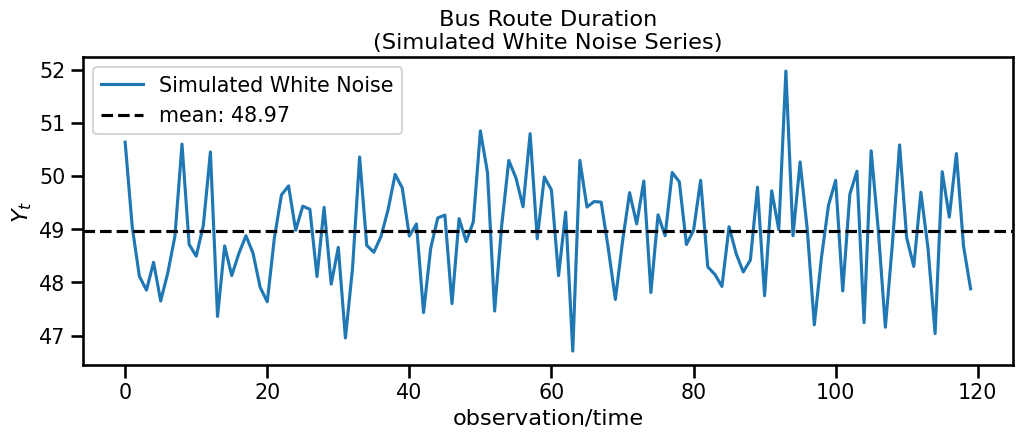

In [ ]:
# Plotting the white noise series with annotated mean
ax = ts_white_noise.plot()
ax.set(title='Bus Route Duration\n(Simulated White Noise Series)',
       ylabel='$Y_t$', xlabel='observation/time');
ax.axhline( ts_white_noise.mean(),  color='k', ls='--',
           label=f'mean: {ts_white_noise.mean():.2f}');
ax.legend();

In [ ]:
# Running the adfuller test to demonstrate return
tsa.adfuller(ts_white_noise)

(np.float64(-11.133859534698887),
 np.float64(3.2317307055655433e-20),
 0,
 119,
 {'1%': np.float64(-3.4865346059036564),
  '5%': np.float64(-2.8861509858476264),
  '10%': np.float64(-2.579896092790057)},
 np.float64(295.21163114049114))

In [ ]:
# Saving each output separately
(test_stat, pval, nlags, nobs, crit_vals_d, icbest) = tsa.adfuller(ts_white_noise)

In [ ]:
# Saving the most important results as a dictionary
adfuller_results = {'Test Statistic': test_stat,
                    "# of Lags Used":nlags,
                   '# of Observations':nobs,
                    'p-value': round(pval,6)}

In [ ]:
# Adding interpretation of p-value to dictionary
alpha =.05
adfuller_results['sig/stationary?'] = pval < alpha
adfuller_results

{'Test Statistic': np.float64(-11.133859534698887),
 '# of Lags Used': 0,
 '# of Observations': 119,
 'p-value': np.float64(0.0),
 'sig/stationary?': np.True_}

In [ ]:
# Convert dictionary of results to a dataframe
adfuller_df = pd.DataFrame(adfuller_results, index=['AD Fuller Test'])
adfuller_df

,Test Statistic,# of Lags Used,# of Observations,p-value,sig/stationary?
AD Fuller Test,-11.13386,0,119,0.0,True


In [ ]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [ ]:
# Testing the function
adfuller_results = get_adfuller_results(ts_white_noise, label='White Noise')
adfuller_results

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
White Noise,-11.13386,0,119,0.0,0.05,True


#**Autocorrelation**

#Checking for Autocorrelation with 1 time lag

In [ ]:
# Shift the data one step
ts_lag1 = ts_white_noise.shift(1)
ts_lag1 = ts_lag1.rename('Lag 1')
ts_lag1.head()

,Lag 1
0,NaN
1,50.635483
2,49.037336
3,48.115850
4,47.856808


In [ ]:
# Combine original ts + with lag 1
ts_lagged = pd.concat([ts_white_noise,ts_lag1], axis=1)
ts_lagged.head()

,Simulated White Noise,Lag 1
0,50.635483,NaN
1,49.037336,50.635483
2,48.115850,49.037336
3,47.856808,48.115850
4,48.378634,47.856808


In [ ]:
# Checking for correlation
ts_lagged.corr()

,Simulated White Noise,Lag 1
Simulated White Noise,1.000000,-0.021783
Lag 1,-0.021783,1.000000


#Checking for Autocorrelation with many time lags

In [ ]:
# Generate 20 time-shifted columns
ts_lagged = pd.DataFrame()
total_shifts = 20
for t in range(0,total_shifts+1):
    ts_lagged[f"Lag {t}"] =  ts_white_noise.shift(t)
ts_lagged.head()

,Lag 0,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,...,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15,Lag 16,Lag 17,Lag 18,Lag 19,Lag 20
0,50.635483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,49.037336,50.635483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,48.115850,49.037336,50.635483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,47.856808,48.115850,49.037336,50.635483,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,48.378634,47.856808,48.115850,49.037336,50.635483,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Calculate correlations for all values
corr = ts_lagged.corr()
corr.head()

,Lag 0,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,...,Lag 11,Lag 12,Lag 13,Lag 14,Lag 15,Lag 16,Lag 17,Lag 18,Lag 19,Lag 20
Lag 0,1.000000,-0.021783,-0.064080,-0.018734,-0.014180,-0.118503,0.018079,0.064780,-0.173773,-0.128825,...,0.058375,0.038630,-0.037089,0.075861,0.021654,0.175557,0.166579,-0.028704,-0.282454,-0.125067
Lag 1,-0.021783,1.000000,-0.024832,-0.050657,-0.016234,-0.002859,-0.141524,0.014664,0.073168,-0.182525,...,0.142978,0.056308,0.019034,-0.037182,0.094835,0.001457,0.191472,0.176576,-0.043111,-0.274006
Lag 2,-0.064080,-0.024832,1.000000,-0.021312,-0.050016,-0.013321,-0.008398,-0.142619,0.016912,0.071255,...,-0.127894,0.142397,0.051440,0.019082,-0.032922,0.090528,0.005322,0.194548,0.173809,-0.039859
Lag 3,-0.018734,-0.050657,-0.021312,1.000000,-0.025063,-0.066142,0.013100,-0.003901,-0.154446,0.026492,...,-0.210015,-0.126081,0.172880,0.051795,-0.002686,-0.007229,0.074885,-0.005278,0.215711,0.161757
Lag 4,-0.014180,-0.016234,-0.050016,-0.025063,1.000000,-0.028093,-0.062291,0.013955,-0.005708,-0.153189,...,0.071136,-0.209615,-0.123666,0.172903,0.048696,0.001656,-0.010319,0.073314,-0.002383,0.214486


In [ ]:
# Slice out the original ts (lag 0)
auto_corr = corr['Lag 0']
auto_corr

,Lag 0
Lag 0,1.000000
Lag 1,-0.021783
Lag 2,-0.064080
Lag 3,-0.018734
Lag 4,-0.014180
Lag 5,-0.118503
Lag 6,0.018079
Lag 7,0.064780
Lag 8,-0.173773
Lag 9,-0.128825


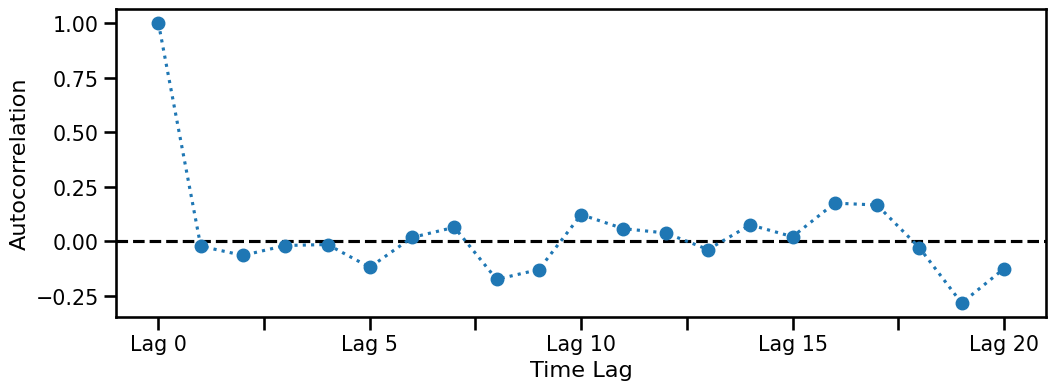

In [ ]:
# Plot the calculated correlations
ax = auto_corr.plot(style='o:')
ax.axhline(0, color='k', ls='--', zorder=-1);
ax.set(ylabel='Autocorrelation', xlabel='Time Lag');

#Statsmodels plot_acf

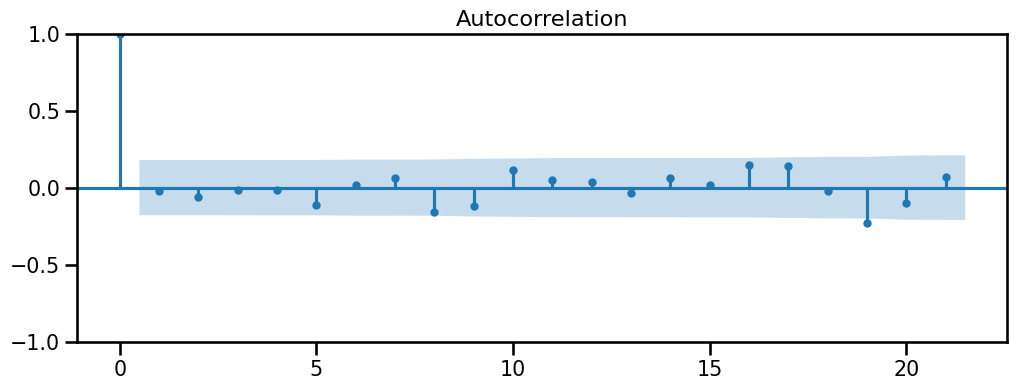

In [ ]:
# Plotting autocorrelation with built in function
fig = tsa.graphics.plot_acf(ts_white_noise);

#Random Walk Time Series

In [ ]:
# Calculating a simulated random walk
first_t = 150
y_walk = [first_t]
n_lags=120
for t in range(1,n_lags):
    # get the previous time lag's value
    y_prev_t = y_walk[t-1]

    # Get new noise
    noise_t = np.random.normal(size=1)

    # Add noise on to previous value
    y_t = y_prev_t + noise_t[0] # slicing 0 to get value instead of arrays
    y_walk.append(y_t)

ts_rand_walk = pd.Series(y_walk, name='Simulated Random Walk')
ts_rand_walk

,Simulated Random Walk
0,150.000000
1,148.598865
2,147.131094
3,148.014590
4,147.161973
...,...
115,153.871576
116,152.788941
117,153.142111
118,155.103555


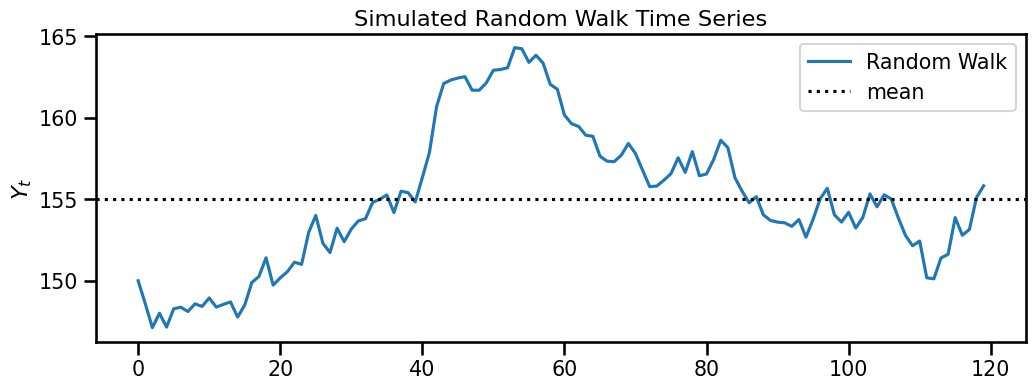

In [ ]:
ax = ts_rand_walk.plot(label='Random Walk')
ax.set(ylabel='$Y_t$', title='Simulated Random Walk Time Series');
ax.axhline(ts_rand_walk.mean(), color='black', ls=':', label='mean');
ax.legend();

#Check for Stationarity with Ad Fuller Test

In [ ]:
# Test random walk forstationarity
get_adfuller_results(ts_rand_walk)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.442588,0,119,0.561697,0.05,False


#Create ACF Plot for Random Walk

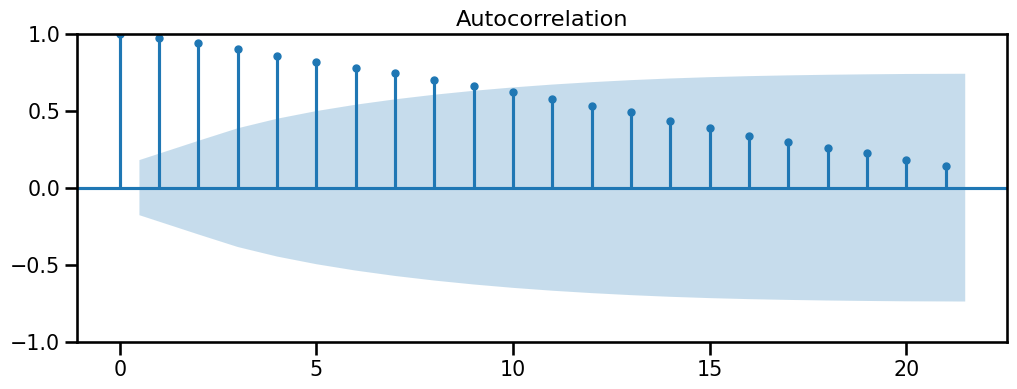

In [ ]:
# Check for autocorrelation
tsa.graphics.plot_acf(ts_rand_walk);

#Differencing

In [ ]:
# Orignal random walk
ts_rand_walk.head()

,Simulated Random Walk
0,150.000000
1,148.598865
2,147.131094
3,148.014590
4,147.161973


In [ ]:
# Differenced random walk
ts_rand_walk.diff().head()

,Simulated Random Walk
0,NaN
1,-1.401135
2,-1.467771
3,0.883495
4,-0.852617


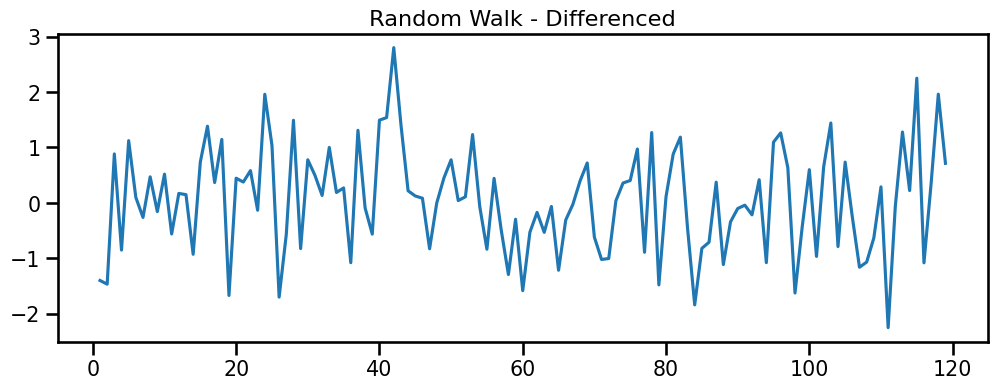

In [ ]:
# Plot the differenced random walk
ts_rand_walk_diff = ts_rand_walk.diff().dropna()
ts_rand_walk_diff.plot(title='Random Walk - Differenced');

#Check for Stationarity with Ad Fuller Test

In [ ]:
# Test differenced random walk for stationarity
get_adfuller_results(ts_rand_walk_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-10.109419,0,118,0.0,0.05,True


#Check for Autocorrelation with ACF Plot

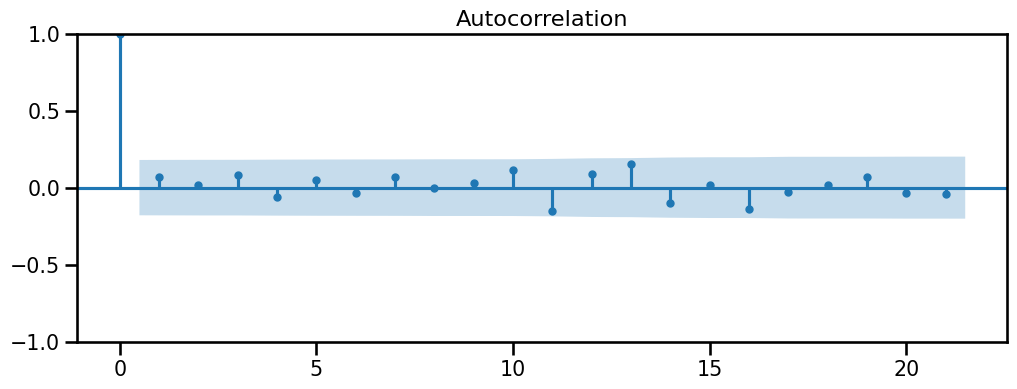

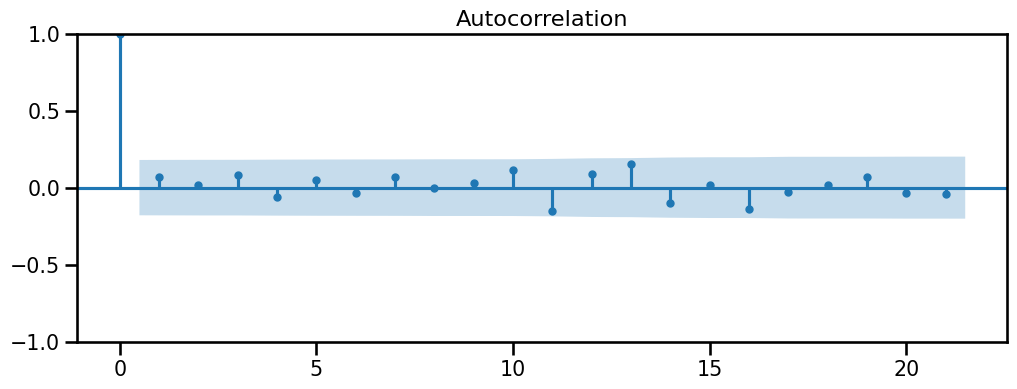

In [ ]:
# Check differenced random walk for autocorrelation
tsa.graphics.plot_acf(ts_rand_walk_diff)

#Random Walk with a Drift

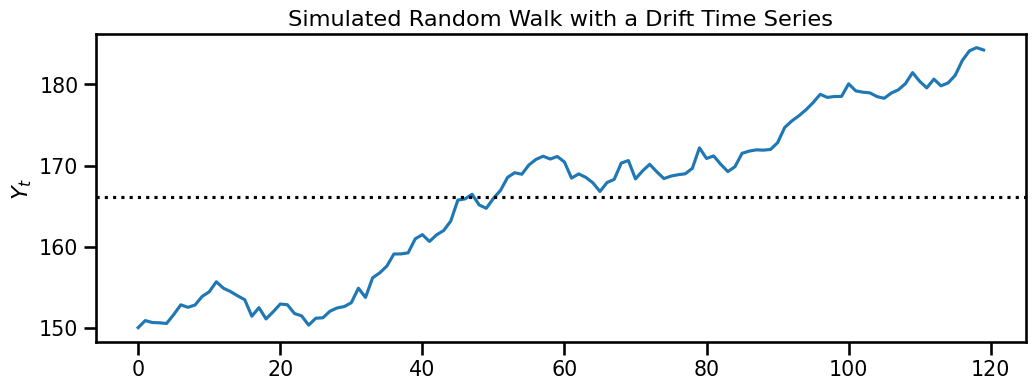

In [ ]:
first_t = 150
c = .3
y_walk_drift = [first_t]
for t in range(1,n_lags):
    # get the previous time lag's value
    y_prev_t = y_walk_drift[t-1]

    # Get new noise
    noise_t = np.random.normal(size=1)
    # Add noise on to previous value
    y_t = c + y_prev_t + noise_t[0]# slicing 0 to get value instead of arrays
    y_walk_drift.append(y_t)

ts_rand_walk_drift = pd.Series(y_walk_drift, name = "Simulated Random walk (+dift)")
ax = ts_rand_walk_drift.plot()
ax.set(ylabel='$Y_t$', title='Simulated Random Walk with a Drift Time Series');
ax.axhline(ts_rand_walk_drift.mean(), color='black', ls=':');

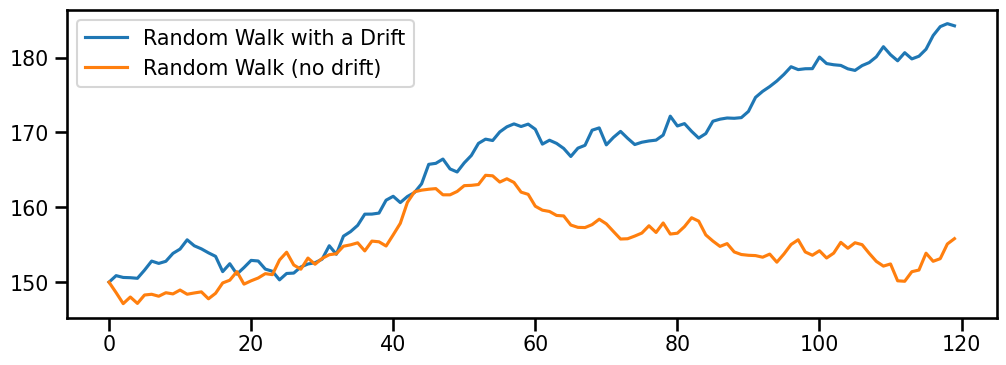

In [ ]:
# compare random walk with a drift vs without
ax = ts_rand_walk_drift.plot(label='Random Walk with a Drift')
ts_rand_walk.plot(ax=ax, label='Random Walk (no drift)')
ax.legend();

#Check for Stationarity with Ad Fuller Test

In [ ]:
# Test random walk with a drift for stationarity
get_adfuller_results(ts_rand_walk_drift)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-0.189886,0,119,0.939716,0.05,False


#Check for Autocorrelation with ACF Plot

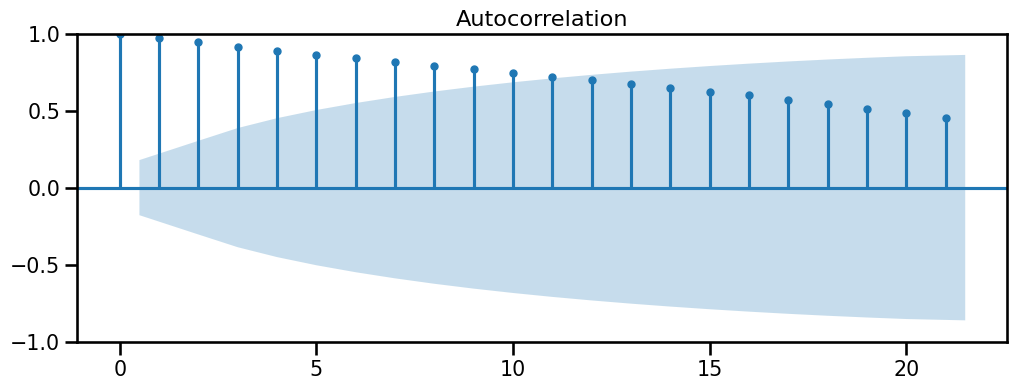

In [ ]:
# Test random walk a with a drift for autocorrelation
tsa.graphics.plot_acf(ts_rand_walk_drift);

#Differencing

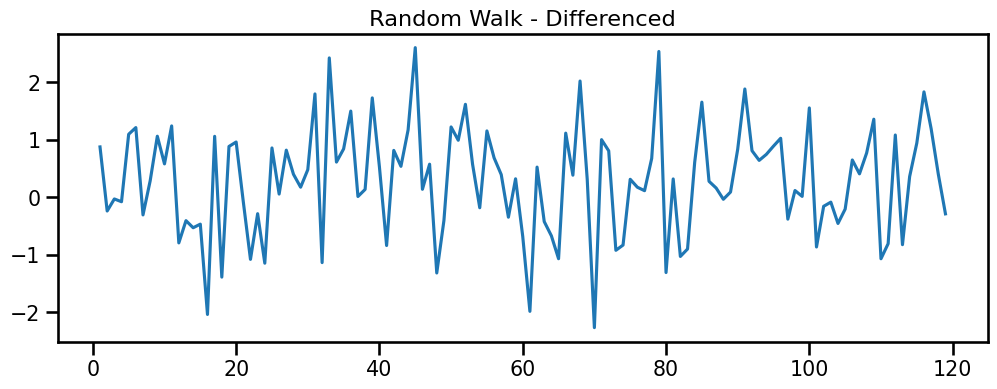

In [ ]:
# Difference the random walk with a drift
ts_rand_walk_drift_diff = ts_rand_walk_drift.diff().dropna()
# Visualize the differenced random walk with a drift
ts_rand_walk_drift_diff.plot(title='Random Walk - Differenced');

#Check for Stationarity with Ad Fuller Test

In [ ]:
# Confirm that a differenced random walk with drift is stationary
get_adfuller_results(ts_rand_walk_drift_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-10.45481,0,118,0.0,0.05,True


#Check for Autocorrelation

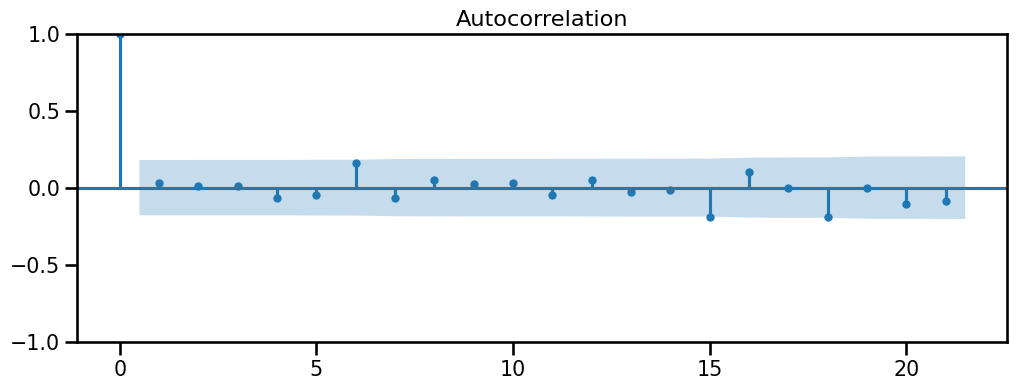

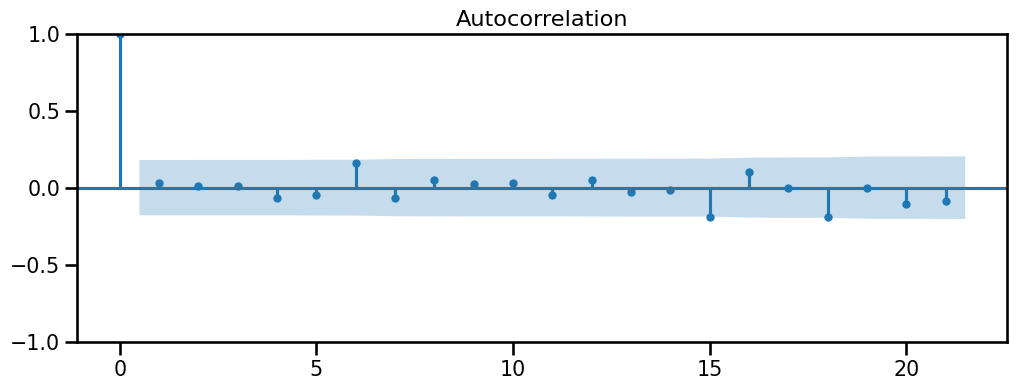

In [ ]:
# Check the differenced random walk with drift for autocorrelation
tsa.graphics.plot_acf(ts_rand_walk_drift_diff)